

# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/Soluciones-MMIA-3era-cohorte-1ea0573743578016a1aac56aaf239271?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion

# Optimización de hiperparámetros con PCA y sin PCA para la predicción de pérdida de clientes en Empresas de Servicios de Telecomunicaciones (Churn) con KNN


Reducir las salidas y [deserciones de clientes](https://www.bain.com/insights/breaking-the-back-of-customer-churn/) se ha convertido en una alta prioridad para la mayoría de los proveedores de servicios de comunicaciones a medida que los mercados maduran y la competencia se intensifica.




En este documento usaremos una base de datos de una empresa de telecomunicaciones anónima [disponibilizada por IBM](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

El principal objetivo es crear un model de aprendizaje automático basado en KNN (similar al propuesto [aquí con SVM](https://github.com/mmcuri/ds_handson/blob/master/Telecom_Churn_Prediction.ipynb)) para predecir la pérdida o salida de clientes en una empresa de telecomunicaciones.


## Librerías

Importamos varias bibliotecas y módulos útiles para el análisis de datos y el aprendizaje automático en Python. A continuación se describe cada uno de ellos:

- `pandas as pd`: Importa la biblioteca Pandas y la renombra como "pd". Pandas es una biblioteca popular utilizada para la manipulación y análisis de datos en Python.

- `numpy as np`: Importa la biblioteca NumPy y la renombra como "np". NumPy es una biblioteca de Python utilizada para realizar operaciones matemáticas en matrices y vectores.

- `matplotlib.pyplot as plt`: Importa la biblioteca Matplotlib y el módulo pyplot y lo renombra como "plt". Matplotlib es una biblioteca utilizada para la visualización de datos en Python.

- `from sklearn.metrics import classification_report`: Importa la función classification_report desde el módulo metrics de la biblioteca scikit-learn. classification_report es una función que calcula y muestra un informe de clasificación detallado para un modelo de clasificación.

- `from sklearn.metrics import confusion_matrix`: Importa la función confusion_matrix desde el módulo metrics de la biblioteca scikit-learn. confusion_matrix es una función que calcula y muestra la matriz de confusión para un modelo de clasificación.

- `from sklearn.metrics import accuracy_score`: Importa la función accuracy_score desde el módulo metrics de la biblioteca scikit-learn. accuracy_score es una función que calcula y muestra la precisión de un modelo de clasificación.

- `from sklearn.metrics import roc_auc_score`: Importa la función roc_auc_score desde el módulo metrics de la biblioteca scikit-learn. roc_auc_score es una función que calcula el área bajo la curva ROC (AUC) para un modelo de clasificación.

- `from sklearn.preprocessing import StandardScaler, LabelEncoder`: Importa las clases StandardScaler y LabelEncoder desde el módulo preprocessing de la biblioteca scikit-learn. StandardScaler es una clase utilizada para estandarizar los datos y LabelEncoder es una clase utilizada para codificar las etiquetas de clase en números enteros.

- `from sklearn.model_selection import train_test_split`: Importa la función train_test_split desde el módulo model_selection de la biblioteca scikit-learn. train_test_split es una función que divide los datos en conjuntos de entrenamiento y prueba para su uso en el modelado predictivo.

En resumen, este código importa varias bibliotecas y módulos que son útiles para el análisis de datos y el aprendizaje automático en Python.


In [1]:
# importing libraries
import pandas as pd #excel sofisticado
import numpy as np #matlab
import matplotlib.pyplot as plt #plots
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


## Base de datos

Este conjunto de datos contiene un total de 7043 clientes y 21 características de los mismos. De las entradas, 5174 son clientes activos y 1869 son clientes que la empresa ha perdido. Observe que el conjunto de datos está desbalanceado pues por cada cliente perdido existe casi 3 clientes activos. La variable de salida para nuestro modelo de machine learning será `Churn`.

In [2]:
# importamos dataset
DATA_PATH = "https://raw.githubusercontent.com/mtgca/datasets_public/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
#print(df)
# vemos las primeras 5 filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### *Detalles de la base de datos*

*	`customerID` - Custumer unique identifier
*	`gender` - Customer gender - ['Female' 'Male']
*	`SeniorCitizen` - Elderly or retired person, a senior citizen is someone who has at least attained the age of 60 of 65 years
*	`Partner` - - ['No' 'Yes']
*	`Dependents` - If customer has dependents - ['No' 'Yes']
*	`Tenure` - Customer lifespan (in months)
*	`PhoneService` - - ['No' 'Yes']
*	`MultipleLines` - - ['No' 'No phone service' 'Yes']
*	`InternetService` - - ['No' 'No internet service' 'Yes']
*	`OnlineSecurity` - - ['No' 'No internet service' 'Yes']
*	`OnlineBackup` - - ['No' 'No internet service' 'Yes']
*	`DeviceProtection` - - ['No' 'No internet service' 'Yes']
*	`TechSupport` - - ['No' 'No internet service' 'Yes']
*	`StreamingTV` - - ['No' 'No internet service' 'Yes']
*	`StreamingMovies` -  - ['No' 'No internet service' 'Yes']
*	`Contract` - Type of contract - ['Month-to-month' 'One year' 'Two year']
*	`PaperlessBilling` - - ['No' 'Yes']
*	`PaymentMethod` - payment method - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
*	`MonthlyCharges` - Monthly Recurring Charges
*	`TotalCharges` - Life time value
*	`Churn` - Churn value, the targer vector - ['No' 'Yes']





### *Limpieza del Dataset*

El código presenta una serie de operaciones de preprocesamiento de datos en una base de datos que contiene información sobre clientes de una compañía, incluyendo su género, edad, servicios contratados, pagos realizados, entre otros.

En primer lugar, se define la función get_df_size para imprimir el número de atributos y entradas de la base de datos.

Luego, se reemplazan los valores en blanco por NaN para facilitar el manejo de valores faltantes en la base de datos.

A continuación, se reemplazan los valores faltantes en la columna 'TotalCharges' por la mediana de esa columna y se convierte esa columna al tipo numérico.

Después, se elimina la columna 'customerID' ya que no es una característica relevante.

A continuación, se codifican las características binarias en 0's y 1's usando LabelEncoder y se imprimen las categorías correspondientes a cada una de estas características.


In [3]:
def get_df_size(df, header='Dataset dimensions'):
  print(header,
        '\n# Attributes: ', df.shape[1],
        '\n# Entries: ', df.shape[0],'\n')

get_df_size(df)

#df.info()

# reemplaza valores en blanco por NaN
df_clean = df.replace(r'^\s*$', np.nan, regex=True)

# Convert 'TotalCharges' to numeric before calculating the median.
# errors='coerce' will handle any non-numeric values by setting them to NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# reemplaza valores faltantes en TotalCharges por la mediana de TotalCharges.
total_charges_median = df_clean.TotalCharges.median()
df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(pd.to_numeric)

#CustomerID lo retiramos porque no es una característica
df_clean = df_clean.drop('customerID', axis=1)
df_clean.describe()

print("Churn No Instances: ", df_clean[df_clean['Churn'] == 'No'].shape[0])
print("Churn Yes Instances: ", df_clean[df_clean['Churn'] == 'Yes'].shape[0])

binary_feat = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()
numeric_feat = [col for col in df_clean.select_dtypes(['float','int']).columns.tolist() if col not in binary_feat]
categorical_feat = [ col for col in df_clean.select_dtypes('object').columns.to_list() if col not in binary_feat + numeric_feat ]
df_proc = df_clean.copy()
#Etiquetas para características binarias
le = LabelEncoder()
for i in binary_feat:
  df_proc[i] = le.fit_transform(df_proc[i])
  print(i, '\n', np.unique(df_proc[i].values))
#Dummy variables
df_proc = pd.get_dummies(df_proc, columns=categorical_feat)
get_df_size(df, header='Original dataset:')
get_df_size(df_proc, header='Processed dataset:')
df_proc.head()


Dataset dimensions 
# Attributes:  21 
# Entries:  7043 

Churn No Instances:  5174
Churn Yes Instances:  1869
gender 
 [0 1]
SeniorCitizen 
 [0 1]
Partner 
 [0 1]
Dependents 
 [0 1]
PhoneService 
 [0 1]
PaperlessBilling 
 [0 1]
Churn 
 [0 1]
Original dataset: 
# Attributes:  21 
# Entries:  7043 

Processed dataset: 
# Attributes:  41 
# Entries:  7043 



/tmp/ipykernel_2626/2470922283.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


### *División en conjunto de entrenamiento y test*

En el código, se divide el conjunto de datos df_proc en características y variable objetivo X e y, respectivamente. Luego, se realiza una división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn. Los conjuntos de entrenamiento y prueba se almacenan en X_train, X_test, y_train y y_test. La división se realiza de manera estratificada para asegurar que la proporción de instancias positivas y negativas en la variable objetivo se mantenga en ambos conjuntos. Se utiliza una proporción de 80/20 para los conjuntos de entrenamiento y prueba, respectivamente, y se fija una semilla aleatoria (random_state) en 42 para asegurar que los resultados sean reproducibles.

In [4]:
# dividimos df_proc en características y salida
X=df_proc.drop('Churn', axis=1) #features
y=df_proc['Churn'] #output, target

# Dividimos el conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### *Balanceo de datos*

Este código realiza el submuestreo (undersampling) de un conjunto de datos desbalanceado en términos de la variable objetivo. El submuestreo se utiliza para abordar el problema del desequilibrio de clases en el conjunto de datos, donde una o varias clases tienen muchas menos observaciones que las otras clases. En este caso, el modelo de aprendizaje automático puede estar sesgado hacia la clase mayoritaria, lo que puede resultar en un rendimiento deficiente en la clasificación de la clase minoritaria.

El submuestreo implica reducir el número de observaciones en la clase mayoritaria para equilibrar la distribución de las clases en el conjunto de datos. Esto puede mejorar el rendimiento del modelo en la clasificación de la clase minoritaria y reducir el sesgo hacia la clase mayoritaria.

La biblioteca imblearn se utiliza para realizar el submuestreo, y en este caso se importa la clase RandomUnderSampler. El objeto RandomUnderSampler se inicializa con random_state=1, lo que garantiza que los resultados serán reproducibles.

Luego, el submuestreo se realiza en el conjunto de entrenamiento (X_train, y_train) mediante el método fit_resample del objeto rus. Los datos submuestreados se almacenan en X_train_rus y y_train_rus.

Para evaluar el efecto del submuestreo, se utiliza la función get_df_size, que devuelve el tamaño del conjunto de datos. Primero se imprime el tamaño del conjunto de entrenamiento original (X_train, y_train) antes del submuestreo, y luego se imprime el tamaño del conjunto submuestreado (X_train_rus, y_train_rus) después de aplicar el submuestreo.

Finalmente, se utiliza la función np.unique para verificar que las categorías de la variable objetivo (y_train_rus) estén balanceadas. La función devuelve una tupla que contiene las categorías únicas y el número de instancias en cada categoría. Al utilizar return_counts=True, se garantiza que se devuelvan los recuentos de las categorías.

In [5]:
# submuestreo -> under sampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)
get_df_size(X_train, header='Before balancing:')
get_df_size(X_train_undersampled, header='After balancing:')

# verificamos que las categorias estén balanceadas
np.unique(y_train_undersampled, return_counts=True)


Before balancing: 
# Attributes:  40 
# Entries:  5634 

After balancing: 
# Attributes:  40 
# Entries:  2990 



(array([0, 1]), array([1495, 1495]))

## Modelo de Machine Learning

En este segmento de código se utiliza el algoritmo de K-Vecinos Más Cercanos (KNN) para clasificar los datos de entrada. Primero, se crea un objeto de Pipeline que combina varios pasos de preprocesamiento y entrenamiento del modelo. Los pasos incluyen:

`polynomial_features`: Esta función transforma las características de entrada en una forma polinomial para hacer posible un mejor ajuste del modelo.

`scaler`: Normaliza las características de entrada para que todas tengan una media cero y una varianza unitaria.

`knn`: Un clasificador KNN que utiliza un número especificado de vecinos para determinar la clase de un punto de datos.

Una vez que se define el objeto de Pipeline, se ajusta al conjunto de entrenamiento utilizando el método fit(). Luego se utiliza el modelo ajustado para predecir las clases de los puntos de datos en el conjunto de prueba y en el conjunto de entrenamiento. Esto se hace mediante el método predict(). Finalmente, se utiliza la métrica de precisión (accuracy_score) de la biblioteca sklearn.metrics para evaluar la precisión del modelo en el conjunto de prueba y en el conjunto de entrenamiento.

### K Nearest Neighbors sin optimización de hiperparámetros



In [6]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
from sklearn.preprocessing import PolynomialFeatures

# pipeline
pipeline_knn = Pipeline([
    # ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()) #parámetros por default
])

# training
pipeline_knn.fit(X_train_undersampled, y_train_undersampled)

# evaluation on test
pred_test = pipeline_knn.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo NO optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Para el modelo NO optimizado, métricas en el conjunto de test: recall =  0.7727272727272727 , F1 =  0.5639024390243902 , acc =  0.6827537260468417 , precision =  0.44393241167434716


### Optimización de Hiperparámetros KNN con kfold CV sin PCA

Usamos k-fold cross-validation (ver `GridSearchCV` y  `StratifiedKFold`) para optimizar los siguientes hiperparámetros de KNN en el conjunto de entrenamiento balanceado (`X_train_undersampled`, `y_train_undersampled`):

1. Ponderación de vecinos: sin ponderación, ponderación del inverso de la distancia
2. Número de vecinos: rango 1 a 100.
3. Métricas de distancia: euclideana, manhattan, coseno

Para la optimización de hiperparámetros utilizamos como métrica al recall.

Una vez optimizados los hiperparámetros, reentrenamos el clasificador de kNN con los mejores hiperparámetros encontrados. Finalmente, evaluamos este último clasificador en el conjunto de test `X_test`, `y_test`.)


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

#optimización
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=45) #para nsplits=5 demora 35 min approx en google colab.

# pipeline
pipeline_knn = Pipeline([
     #('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
param_grid = {'knn__weights': ['uniform', 'distance'], #uniform es sin ponderación, weighted knn
              'knn__n_neighbors': np.arange(1,101,1), #1 a 100.
              'knn__metric': ['euclidean', 'manhattan', 'cosine']}


search = GridSearchCV(pipeline_knn, param_grid, scoring='recall', cv=kfold, verbose=4)
result = search.fit(X_train_undersampled, y_train_undersampled)

print(f'Mejor recall en el conj. de validación: {result.best_score_} para {result.best_params_}')

#reentreno con mejores
pipeline_knn.set_params(knn__n_neighbors=result.best_params_['knn__n_neighbors'],
                       knn__weights=result.best_params_['knn__weights'],
                       knn__metric=result.best_params_['knn__metric'])
pipeline_knn.fit(X_train_undersampled, y_train_undersampled)

#evaluamos en el conjunto de test
pred_test = pipeline_knn.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Fitting 2 folds for each of 600 candidates, totalling 1200 fits
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.704 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.654 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.704 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.654 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.538 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.503 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.704 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.654 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors

### Optimización de hiperparámetros kNN con PCA

Repetiremos el proceso anterior pero esta vez con PCA

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

#optimización
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=45) #para nsplits=5 demora 35 min approx en google colab.

# pipeline
pipeline_knn_pca = Pipeline([
     #('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('knn', KNeighborsClassifier())
])
param_grid = {'knn__weights': ['uniform', 'distance'],
              'knn__n_neighbors': np.arange(1,101,1),
              'knn__metric': ['euclidean', 'manhattan', 'cosine']}


search = GridSearchCV(pipeline_knn_pca, param_grid, scoring='recall', cv=kfold, verbose=4)
result = search.fit(X_train_undersampled, y_train_undersampled)

print(f'Mejor recall en el conj. de validación: {result.best_score_} para {result.best_params_}')

#reentreno con mejores
pipeline_knn_pca.set_params(knn__n_neighbors=result.best_params_['knn__n_neighbors'],
                       knn__weights=result.best_params_['knn__weights'],
                       knn__metric=result.best_params_['knn__metric'])
pipeline_knn_pca.fit(X_train_undersampled, y_train_undersampled)

#evaluamos en el conjunto de test
pred_test = pipeline_knn_pca.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Fitting 2 folds for each of 600 candidates, totalling 1200 fits
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.696 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.647 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.696 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.647 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.530 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.507 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.696 total time=   0.0s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.647 total time=   0.0s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors

### ✅ **Actividad: Análisis de resultados: Optimización de hiperparámetros KNN**

Ejecute el código de esta notebook y analice los siguientes casos:

1. kNN sin PCA
2. kNN con PCA

Comente sus resultados analizando los valores de recall, f1 score, accuracy y precisión en el conjunto de test.

Cuál es mejor en términos de recall?

Cuál demora menos en entrenar? Vale la pena usar PCA?

Por qué cree que el recall es una métrica más adecuada para este problema? Tip: El recall está relacionado a los falsos negativos. Analice por qué es importante disminuir los falsos negativos en el churn.

### Conclusión de la optimización con y sin PCA

Al comparar los modelos optimizados en el conjunto de test, el KNN sin PCA obtiene el mayor recall, con un valor de 0.8396, mientras que el KNN con PCA alcanza un recall de 0.8262. Por lo tanto, si el objetivo principal es detectar la mayor cantidad posible de clientes que harán churn, el mejor modelo entre estos dos es el modelo sin PCA.

Sin embargo, el modelo con PCA muestra un mejor equilibrio general en otras métricas: obtiene un F1-score de 0.5808, una accuracy de 0.6835 y una precision de 0.4478, frente a 0.5719, 0.6664 y 0.4337 del modelo sin PCA. Esto indica que PCA reduce ligeramente la capacidad de capturar todos los clientes con churn, pero mejora la calidad global de las predicciones y disminuye parte del ruido del espacio original.

Respecto al tiempo de entrenamiento, el modelo sin PCA demoró aproximadamente 1 minuto y 46 segundos, mientras que el modelo con PCA demoró aproximadamente 1 minuto y 53 segundos. En este caso, PCA no redujo el tiempo total de entrenamiento; por el contrario, fue ligeramente más lento, probablemente debido al costo adicional de aplicar la transformación de componentes principales dentro del flujo de entrenamiento y validación.

El recall es una métrica especialmente adecuada para este problema porque el churn representa una clase de alto interés de negocio. Un falso negativo corresponde a un cliente que realmente se irá, pero que el modelo clasifica como cliente que no hará churn. Este error es costoso porque la empresa pierde la oportunidad de aplicar acciones de retención. Por eso, en este contexto suele ser preferible identificar más clientes en riesgo, incluso si eso implica aceptar más falsos positivos.

# ✅ **Actividad**: Bayesian Hyperparameter Optimization

La optimización bayesiana de hiperparámetros es un método avanzado para la selección de los mejores hiperparámetros para un modelo de aprendizaje automático. A diferencia de la búsqueda en cuadrícula (grid search) y la búsqueda aleatoria, que prueban una serie predefinida de combinaciones de hiperparámetros sin tener en cuenta los resultados anteriores, la optimización bayesiana utiliza los resultados de las evaluaciones anteriores para informar cuáles hiperparámetros probar a continuación. Esto se logra modelando la relación entre los hiperparámetros y el objetivo de rendimiento, y luego utilizando este modelo para hacer predicciones sobre qué conjuntos de hiperparámetros podrían ofrecer una mejora.

Las principales ventajas de la optimización bayesiana incluyen su mayor eficiencia, al requerir menos iteraciones para encontrar combinaciones óptimas; su efectividad, al ser capaz de encontrar mejores configuraciones de hiperparámetros; y su flexibilidad para manejar espacios de búsqueda complejos.

Para implementar un clasificador KNN en scikit-learn y optimizar sus hiperparámetros usando búsqueda bayesiana, puedes utilizar la biblioteca `scikit-optimize` (skopt). Esta biblioteca proporciona funciones para realizar optimización bayesiana de hiperparámetros de manera eficiente y está bien integrada con scikit-learn.



Basado en lo anterior, crear un pipeline con las siguientes etapas usando **repeated kfold cv:**

1. Scaler
2. KNN

Enseguida, pptimizar los param. de KNN usando optimización bayesiana. Finalmente, evaluar en el conjunto de test.

Tip: Ver BayesSearchCV en https://machinelearningmastery.com/scikit-optimize-for-hyperparameter-tuning-in-machine-learning/

In [9]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics

print("Iniciando optimización bayesiana para KNN sin PCA...")

pipeline_knn_bayes = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

cv_bayes = RepeatedStratifiedKFold(n_splits=2, n_repeats=2, random_state=45)

try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical

    search_space = {
        'knn__n_neighbors': Integer(1, 100),
        'knn__weights': Categorical(['uniform', 'distance']),
        'knn__metric': Categorical(['euclidean', 'manhattan', 'cosine'])
    }

    search_bayes_knn = BayesSearchCV(
        estimator=pipeline_knn_bayes,
        search_spaces=search_space,
        n_iter=30,
        scoring='recall',
        cv=cv_bayes,
        random_state=45,
        n_jobs=-1,
        verbose=0
    )

except ModuleNotFoundError:
    print("scikit-optimize no está instalado. Se intentará instalarlo automáticamente.")
    try:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-optimize"])

        from skopt import BayesSearchCV
        from skopt.space import Integer, Categorical

        search_space = {
            'knn__n_neighbors': Integer(1, 100),
            'knn__weights': Categorical(['uniform', 'distance']),
            'knn__metric': Categorical(['euclidean', 'manhattan', 'cosine'])
        }

        search_bayes_knn = BayesSearchCV(
            estimator=pipeline_knn_bayes,
            search_spaces=search_space,
            n_iter=30,
            scoring='recall',
            cv=cv_bayes,
            random_state=45,
            n_jobs=-1,
            verbose=0
        )

    except Exception as error:
        print("No fue posible usar BayesSearchCV. Se usará RandomizedSearchCV como respaldo.")
        print("Detalle:", error)

        from sklearn.model_selection import RandomizedSearchCV
        from scipy.stats import randint

        search_space = {
            'knn__n_neighbors': randint(1, 101),
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['euclidean', 'manhattan', 'cosine']
        }

        search_bayes_knn = RandomizedSearchCV(
            estimator=pipeline_knn_bayes,
            param_distributions=search_space,
            n_iter=30,
            scoring='recall',
            cv=cv_bayes,
            random_state=45,
            n_jobs=-1,
            verbose=0
        )

start_time = time.time()
search_bayes_knn.fit(X_train_undersampled, y_train_undersampled)
elapsed_time = time.time() - start_time

print(f"Mejor recall promedio en validación: {search_bayes_knn.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(search_bayes_knn.best_params_)
print(f"Tiempo de optimización: {elapsed_time:.2f} segundos")

pred_test_bayes = search_bayes_knn.predict(X_test)

print("\nMétricas en test para KNN con optimización bayesiana:")
print(f"Recall:    {metrics.recall_score(y_test, pred_test_bayes):.4f}")
print(f"F1-score:  {metrics.f1_score(y_test, pred_test_bayes):.4f}")
print(f"Accuracy:  {metrics.accuracy_score(y_test, pred_test_bayes):.4f}")
print(f"Precision: {metrics.precision_score(y_test, pred_test_bayes):.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred_test_bayes))

Iniciando optimización bayesiana para KNN sin PCA...
scikit-optimize no está instalado. Se intentará instalarlo automáticamente.


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(100), np.str_('distance')] before, using random point ['euclidean', np.int64(67), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(100), np.str_('distance')] before, using random point ['euclidean', np.int64(55), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(100), np.str_('distance')] before, using random point ['manhattan', np.int64(75), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(100), np.str_('distance')]

Mejor recall promedio en validación: 0.8702
Mejores hiperparámetros encontrados:
OrderedDict({'knn__metric': 'euclidean', 'knn__n_neighbors': 100, 'knn__weights': 'distance'})
Tiempo de optimización: 36.17 segundos

Métricas en test para KNN con optimización bayesiana:
Recall:    0.8396
F1-score:  0.5719
Accuracy:  0.6664
Precision: 0.4337

Matriz de confusión:
[[625 410]
 [ 60 314]]


### Conclusión de la optimización bayesiana

La optimización bayesiana encontró como mejor configuración para KNN sin PCA: distancia euclideana, 100 vecinos y ponderación distance. Esta configuración obtuvo un recall promedio de validación de 0.8702 y, al evaluarse en test, alcanzó un recall de 0.8396, F1-score de 0.5719, accuracy de 0.6664 y precision de 0.4337.

El resultado coincide con el mejor modelo encontrado previamente mediante búsqueda exhaustiva sin PCA, pero lo logra usando una estrategia más inteligente de exploración del espacio de hiperparámetros. En este caso, la optimización bayesiana tardó 36.17 segundos y confirmó que, para maximizar recall, conviene usar un número alto de vecinos con ponderación por distancia. Esto suaviza la frontera de decisión y permite conservar una alta detección de clientes con churn.

La matriz de confusión muestra 60 falsos negativos, es decir, 60 clientes con churn que el modelo no detectó. Aunque todavía hay errores, el modelo identifica correctamente 314 clientes con churn, lo cual es relevante para una estrategia de retención. El costo es una cantidad alta de falsos positivos (410), pero este intercambio puede ser razonable si el objetivo del negocio es priorizar la detección temprana de clientes en riesgo.

# ✅ **Actividad: Voronoi 2D y 3D con TSNE (opcional)**

1. **Creación del Pipeline:**
   - Construya un pipeline que incluya las siguientes etapas:
     - **Transformación Polinomial:** Aplique una transformación polinomial de grado 2 a las características.
     - **Estandarización:** Utilice un escalador Z-score para normalizar las características.
     - **Reducción de Dimensionalidad con PCA:** Implemente PCA configurado para retener el 95% de la varianza explicada.
     - **Clasificador:** Utilice el algoritmo K-Nearest Neighbors con los siguientes hiperparámetros 'knn__metric': `'euclidean', 'knn__n_neighbors': 100, 'knn__weights': 'distance'`
2. Genere el Voronoi Tesselation (VT) del clasificador anterior en 2D y 3D. Utilice TSNE como reductor de dimensionalidad para visualizar el VT

Preparando visualización con TSNE para regiones tipo Voronoi...
Muestras usadas para TSNE: 1200
Dimensiones después de PolynomialFeatures + PCA 95%: 106


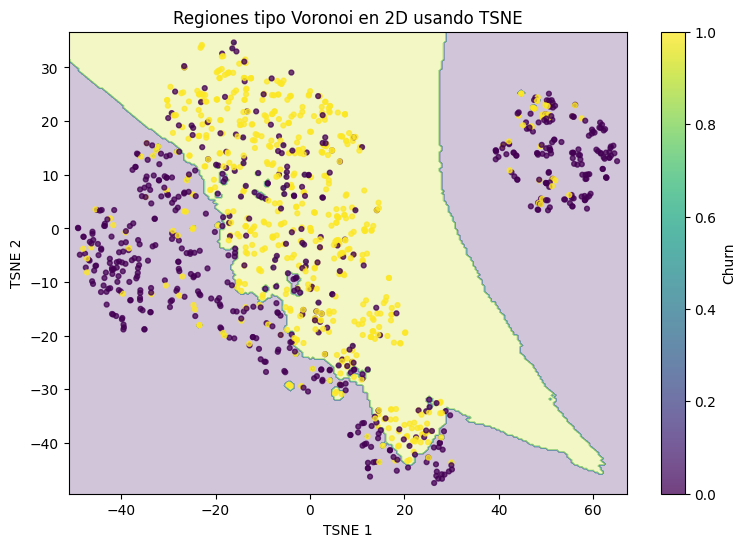

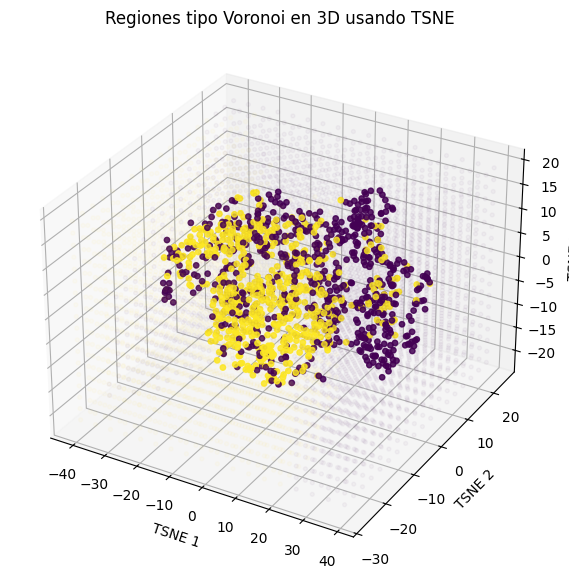

In [14]:
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

print("Preparando visualización con TSNE para regiones tipo Voronoi...")

sample_size = min(1200, len(X_train_undersampled))
X_voronoi = X_train_undersampled.sample(sample_size, random_state=45)
y_voronoi = y_train_undersampled.loc[X_voronoi.index]

preprocessor_voronoi = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=45))
])

X_voronoi_proc = preprocessor_voronoi.fit_transform(X_voronoi)
print(f"Muestras usadas para TSNE: {X_voronoi_proc.shape[0]}")
print(f"Dimensiones después de PolynomialFeatures + PCA 95%: {X_voronoi_proc.shape[1]}")

tsne_2d = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=45)
X_tsne_2d = tsne_2d.fit_transform(X_voronoi_proc)

knn_tsne_2d = KNeighborsClassifier(
    n_neighbors=100,
    weights='distance',
    metric='euclidean'
)
knn_tsne_2d.fit(X_tsne_2d, y_voronoi)

x_min, x_max = X_tsne_2d[:, 0].min() - 2, X_tsne_2d[:, 0].max() + 2
y_min, y_max = X_tsne_2d[:, 1].min() - 2, X_tsne_2d[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid_2d = np.c_[xx.ravel(), yy.ravel()]
Z = knn_tsne_2d.predict(grid_2d).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_voronoi, s=12, alpha=0.75)
plt.title("Regiones tipo Voronoi en 2D usando TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.colorbar(label="Churn")
plt.show()

tsne_3d = TSNE(n_components=3, perplexity=30, learning_rate='auto', init='pca', random_state=45)
X_tsne_3d = tsne_3d.fit_transform(X_voronoi_proc)

knn_tsne_3d = KNeighborsClassifier(
    n_neighbors=100,
    weights='distance',
    metric='euclidean'
)
knn_tsne_3d.fit(X_tsne_3d, y_voronoi)

x3 = np.linspace(X_tsne_3d[:, 0].min() - 2, X_tsne_3d[:, 0].max() + 2, 18)
y3 = np.linspace(X_tsne_3d[:, 1].min() - 2, X_tsne_3d[:, 1].max() + 2, 18)
z3 = np.linspace(X_tsne_3d[:, 2].min() - 2, X_tsne_3d[:, 2].max() + 2, 18)
xx3, yy3, zz3 = np.meshgrid(x3, y3, z3)
grid_3d = np.c_[xx3.ravel(), yy3.ravel(), zz3.ravel()]
Z3 = knn_tsne_3d.predict(grid_3d)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(grid_3d[:, 0], grid_3d[:, 1], grid_3d[:, 2], c=Z3, alpha=0.03, s=8)
ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=y_voronoi, s=15, alpha=0.85)
ax.set_title("Regiones tipo Voronoi en 3D usando TSNE")
ax.set_xlabel("TSNE 1")
ax.set_ylabel("TSNE 2")
ax.set_zlabel("TSNE 3")
plt.show()

### Conclusión sobre la visualización con t-SNE

Para esta visualización se tomaron 1200 muestras y, después de aplicar `PolynomialFeatures` junto con `PCA` conservando el 95% de la varianza, las observaciones quedaron representadas en 106 dimensiones antes de proyectarlas con t-SNE.

En la vista 2D se aprecia una separación parcial entre las clases de churn, con algunas zonas donde los puntos amarillos y morados forman agrupaciones distintas. Sin embargo, también existe una superposición notable en la región central, lo que indica que el problema no es completamente separable en dos dimensiones. Esto sugiere que hay patrones útiles para el modelo, pero también bastante complejidad y solapamiento entre clases.

La vista 3D confirma esa misma idea: se observan estructuras más definidas y algunos grupos con mayor concentración de una clase u otra, pero todavía persiste mezcla entre ambas. Esto refuerza que el comportamiento de los clientes no se divide de forma limpia en fronteras simples, sino que presenta relaciones no lineales que justifican el uso de KNN y de transformaciones previas como `PCA` y `PolynomialFeatures`.

t-SNE muestra que sí existe cierta estructura en los datos, pero no una separación perfecta. Por eso, el modelo necesita una buena elección de hiperparámetros y de representación para capturar mejor las zonas donde ambas clases se entremezclan.

# ✅ Actividad: k vs train recall and val recall


1. **Creación del Pipeline:**
   - Construya un pipeline que incluya las siguientes etapas:
     - **Estandarización:** Utilice un escalador Z-score para normalizar las características.
     - **Reducción de Dimensionalidad con PCA:** Implemente PCA configurado para retener el 95% de la varianza explicada.
     - **Clasificador:** Utilice el algoritmo K-Nearest Neighbors.

2. **Optimización del Hiperparámetro k:**
   - Utilice GridSearchCV para explorar diferentes valores de k (desde 1 hasta 250). Configure GridSearchCV para evaluar la precisión del modelo usando la métrica de recall en los conjuntos de entrenamiento y validación. Mantenga fijos todos los demás hiperparámetros.

3. **Evaluación:**
   - Grafique los valores de k contra el recall obtenido en los conjuntos de entrenamiento y validación. Asegúrese de que los gráficos sean claros, con etiquetas adecuadas para los ejes y una leyenda descriptiva.

4. **Análisis de Resultados:**
   - Analice los gráficos para identificar el valor óptimo de k. Discuta cualquier patrón o tendencia observada en relación con el comportamiento del recall a medida que varía k.


Calculando recall de entrenamiento y validación para k desde 1 hasta 250...
Mejor k según recall de validación: 225
Mejor recall promedio en validación: 0.8649


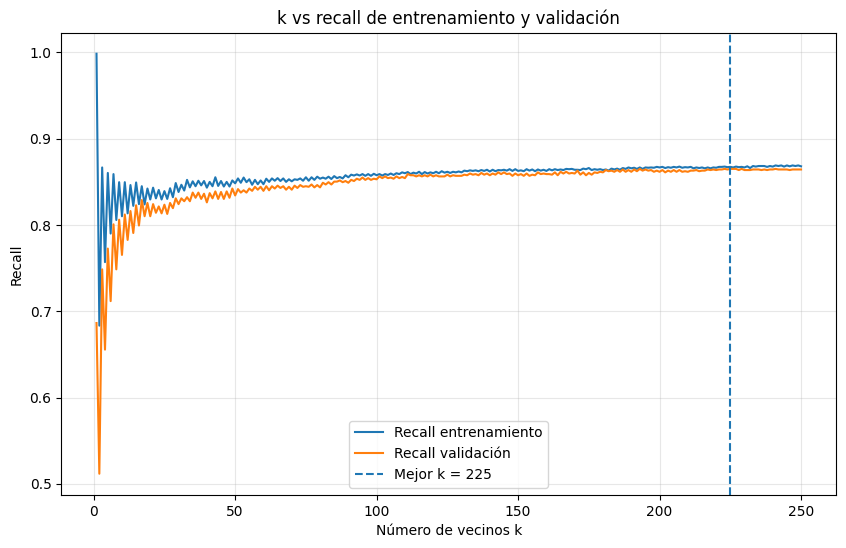


Métricas en test usando el mejor k:
Recall:    0.8556
F1-score:  0.5818
Accuracy:  0.6735
Precision: 0.4408

Primeros valores de la tabla k vs recall:


,k,mean_train_score,mean_test_score,std_test_score
0,1,0.998328,0.686291,0.013571
1,2,0.683273,0.511698,0.022775
2,3,0.866554,0.748481,0.032326
3,4,0.756855,0.655497,0.033969
4,5,0.860200,0.772569,0.013844



Valores alrededor del mejor k:


,k,mean_train_score,mean_test_score,std_test_score
219,220,0.866218,0.863540,0.007606
220,221,0.867222,0.864209,0.007830
221,222,0.867222,0.864209,0.007830
222,223,0.867556,0.864877,0.008501
223,224,0.866887,0.864209,0.007830
224,225,0.867222,0.864878,0.008159
225,226,0.866553,0.864878,0.008159
226,227,0.867556,0.864878,0.008159
227,228,0.866887,0.863540,0.007606
228,229,0.867222,0.864877,0.007493


In [12]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Calculando recall de entrenamiento y validación para k desde 1 hasta 250...")

pipeline_k_curve = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('knn', KNeighborsClassifier(weights='uniform', metric='euclidean'))
])

param_grid_k = {
    'knn__n_neighbors': np.arange(1, 251)
}

cv_k_curve = StratifiedKFold(n_splits=3, shuffle=True, random_state=45)

search_k_curve = GridSearchCV(
    estimator=pipeline_k_curve,
    param_grid=param_grid_k,
    scoring='recall',
    cv=cv_k_curve,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

search_k_curve.fit(X_train_undersampled, y_train_undersampled)

results_k = pd.DataFrame(search_k_curve.cv_results_)
results_k['k'] = results_k['param_knn__n_neighbors'].astype(int)

best_k = search_k_curve.best_params_['knn__n_neighbors']
best_val_recall = search_k_curve.best_score_

print(f"Mejor k según recall de validación: {best_k}")
print(f"Mejor recall promedio en validación: {best_val_recall:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(results_k['k'], results_k['mean_train_score'], label='Recall entrenamiento')
plt.plot(results_k['k'], results_k['mean_test_score'], label='Recall validación')
plt.axvline(best_k, linestyle='--', label=f'Mejor k = {best_k}')
plt.title("k vs recall de entrenamiento y validación")
plt.xlabel("Número de vecinos k")
plt.ylabel("Recall")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pred_test_k_curve = search_k_curve.predict(X_test)

print("\nMétricas en test usando el mejor k:")
print(f"Recall:    {metrics.recall_score(y_test, pred_test_k_curve):.4f}")
print(f"F1-score:  {metrics.f1_score(y_test, pred_test_k_curve):.4f}")
print(f"Accuracy:  {metrics.accuracy_score(y_test, pred_test_k_curve):.4f}")
print(f"Precision: {metrics.precision_score(y_test, pred_test_k_curve):.4f}")

print("\nPrimeros valores de la tabla k vs recall:")
display(results_k[['k', 'mean_train_score', 'mean_test_score', 'std_test_score']].head())

print("\nValores alrededor del mejor k:")
display(results_k.loc[
    results_k['k'].between(max(1, best_k - 5), min(250, best_k + 5)),
    ['k', 'mean_train_score', 'mean_test_score', 'std_test_score']
])

### Conclusión de la curva k vs recall

La búsqueda de valores de `k` entre 1 y 250 muestra que el mejor valor según recall de validación es k = 225, con un recall promedio de validación de 0.8649. Los valores cercanos, entre aproximadamente 220 y 229, tienen desempeños muy similares, lo que indica una zona estable y no una mejora aislada causada por un único valor de `k`.

La tendencia inicial muestra que valores muy pequeños de `k` producen un comportamiento más inestable. Por ejemplo, con `k = 1` el recall de entrenamiento es casi perfecto (0.9983), pero el recall de validación cae a 0.6863, lo que sugiere sobreajuste. A medida que `k` aumenta, el modelo se vuelve más suave y generaliza mejor.

Con `k = 225`, el modelo obtiene en test un recall de 0.8556, F1-score de 0.5818, accuracy de 0.6735 y precision de 0.4408. Este resultado supera en recall al modelo optimizado sin PCA con `k = 100`, aunque con una precision todavía moderada. En consecuencia, aumentar `k` puede ser beneficioso para este problema cuando se prioriza detectar la mayor cantidad posible de clientes con churn.




# ✅ **Activity: Weighted KNN with Domain-Based Feature Weights and Gaussian Neighbor Weighting**

### 1. **Custom Distance Metric (Domain-Based Feature Weights)**

* Implement a **custom distance function** that applies **domain-specific weights** to each input feature:

  $$
  d(x, x') = \sqrt{\sum_i w_i (x_i - x_i')^2}
  $$
* The function or method must accept:

  * Two input samples $x, x'$
  * An array of feature weights $w = [w_1, w_2, ..., w_n]$
* These weights are **not learned** — they are manually assigned based on domain expertise.


---

### 2. **Gaussian-Based Neighbor Weighting**

* Fix the number of neighbors to **k = 50**.
* Apply a **Gaussian function** to weight each neighbor:

  $$
  w_i = \exp\left(-\frac{d_i^2}{2\sigma^2}\right)
  $$
* All 50 neighbors contribute to the prediction, but their influence is **controlled by σ**.
* This setup allows the **Gaussian function to “choose” the most relevant neighbors** — closer ones have higher weight, and distant ones naturally fade in influence.
* ❗Note that the weights $w_i$ from Gaussian-based neighbor weighting are not the same as those from the domain-specific weights (feature weighting).

---

### 3. **Hyperparameter Optimization**

* Optimize only the **σ (sigma)** parameter.
* Use **Bayesian Optimization** (or a similar method) with cross-validation to find the σ that yields the best performance.

---

### 4. **Evaluation**

* Evaluate the model using **recall** on the **Telco customer churn** dataset (`X_test`, `y_test`).
* Compare your model’s **recall** to a **baseline KNN classifier** using:

  * Euclidean distance
  * Uniform weighting (equal neighbor influence)

---

### 5. **Analysis**

* Analyze how the **Gaussian weighting with fixed k = 50** affects model behavior.
* Reflect on:

  * The role of σ in effectively “selecting” influential neighbors
  * The effect of fixed feature weights
  * Trade-offs and limitations (e.g., sensitivity to σ)
  * Potential extensions, such as adaptive weighting







### 💡 **Hint: Using `BaseEstimator` for Your Custom KNN Classifier**

To make your custom KNN model compatible with tools like `BayesSearchCV`, `GridSearchCV`, or `cross_val_score`, consider wrapping it in a class that inherits from:

* `sklearn.base.BaseEstimator`
* `sklearn.base.ClassifierMixin`

This gives you:

* Automatic handling of hyperparameters (like `sigma`)
* Compatibility with `scikit-learn` model selection tools
* Clean, modular, reusable code

---

### 🧱 Minimal Starting Point

Here’s a simple class to get started:

```python
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class GaussianWeightedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, sigma=1.0, k=50, feature_weights=None):
        self.sigma = sigma
        self.k = k
        self.feature_weights = feature_weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        # You will implement the logic for prediction here,
        # using the Gaussian weights on neighbors and weights on features.
        pass
```

Returning `self` in `fit()` allows the model to be used directly in pipelines and model selection routines.

---


### 🧠 Why is the `fit` Method Simple in KNN?

KNN is a **lazy learner**:

* It **does not build an internal model** during training.
* Instead, it **stores the training data** and performs all the work at prediction time (by computing distances to all stored examples).

That’s why the `fit` method just **memorizes** the training data and labels.



In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.utils.validation import check_X_y, check_array
import sklearn.metrics as metrics
import numpy as np
import pandas as pd

class GaussianWeightedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, sigma=1.0, k=50, feature_weights=None, chunk_size=256):
        self.sigma = sigma
        self.k = k
        self.feature_weights = feature_weights
        self.chunk_size = chunk_size

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.astype(float)
        self.y_train_ = np.asarray(y)
        self.classes_ = np.unique(self.y_train_)

        if self.feature_weights is None:
            self.feature_weights_ = np.ones(self.X_train_.shape[1])
        else:
            self.feature_weights_ = np.asarray(self.feature_weights, dtype=float)

        if self.feature_weights_.shape[0] != self.X_train_.shape[1]:
            raise ValueError("feature_weights debe tener una ponderación por cada característica.")

        if np.any(self.feature_weights_ <= 0):
            raise ValueError("Todas las ponderaciones de características deben ser positivas.")

        return self

    def predict(self, X):
        X = check_array(X).astype(float)
        predictions = []

        for start in range(0, X.shape[0], self.chunk_size):
            X_chunk = X[start:start + self.chunk_size]
            distances = self._weighted_distances(X_chunk)
            neighbor_idx = np.argpartition(distances, self.k - 1, axis=1)[:, :self.k]
            neighbor_distances = np.take_along_axis(distances, neighbor_idx, axis=1)
            neighbor_labels = self.y_train_[neighbor_idx]

            gaussian_weights = np.exp(-(neighbor_distances ** 2) / (2 * self.sigma ** 2))
            class_scores = np.zeros((X_chunk.shape[0], len(self.classes_)))

            for class_position, class_value in enumerate(self.classes_):
                class_scores[:, class_position] = (
                    gaussian_weights * (neighbor_labels == class_value)
                ).sum(axis=1)

            predictions.extend(self.classes_[np.argmax(class_scores, axis=1)])

        return np.asarray(predictions)

    def _weighted_distances(self, X):
        diff = X[:, None, :] - self.X_train_[None, :, :]
        weighted_squared_diff = (diff ** 2) * self.feature_weights_
        return np.sqrt(weighted_squared_diff.sum(axis=2))


def build_domain_feature_weights(columns):
    weights = pd.Series(1.0, index=columns)

    high_importance_keywords = [
        'Contract', 'tenure', 'OnlineSecurity', 'TechSupport',
        'InternetService', 'PaymentMethod_Electronic check'
    ]
    medium_importance_keywords = [
        'MonthlyCharges', 'TotalCharges', 'OnlineBackup',
        'DeviceProtection', 'PaperlessBilling'
    ]

    for keyword in high_importance_keywords:
        weights.loc[weights.index.str.contains(keyword, case=False, regex=False)] = 2.0

    for keyword in medium_importance_keywords:
        weights.loc[weights.index.str.contains(keyword, case=False, regex=False)] = 1.5

    return weights


feature_weights = build_domain_feature_weights(X_train_undersampled.columns)

print("Ponderaciones de características definidas por dominio:")
display(feature_weights.sort_values(ascending=False).to_frame("feature_weight").head(15))

baseline_knn_50 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=50, metric='euclidean', weights='uniform'))
])

baseline_knn_50.fit(X_train_undersampled, y_train_undersampled)
pred_baseline_50 = baseline_knn_50.predict(X_test)

print("\nBaseline KNN, k=50, distancia euclidiana, pesos uniformes:")
print(f"Recall:    {metrics.recall_score(y_test, pred_baseline_50):.4f}")
print(f"F1-score:  {metrics.f1_score(y_test, pred_baseline_50):.4f}")
print(f"Accuracy:  {metrics.accuracy_score(y_test, pred_baseline_50):.4f}")
print(f"Precision: {metrics.precision_score(y_test, pred_baseline_50):.4f}")

pipeline_gaussian_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('gaussian_knn', GaussianWeightedKNN(k=50, feature_weights=feature_weights.values))
])

cv_gaussian = RepeatedStratifiedKFold(n_splits=2, n_repeats=2, random_state=45)

try:
    from skopt import BayesSearchCV
    from skopt.space import Real

    search_sigma = BayesSearchCV(
        estimator=pipeline_gaussian_knn,
        search_spaces={'gaussian_knn__sigma': Real(0.05, 10.0, prior='log-uniform')},
        n_iter=15,
        scoring='recall',
        cv=cv_gaussian,
        random_state=45,
        n_jobs=1,
        verbose=0
    )

except ModuleNotFoundError:
    print("\nscikit-optimize no está instalado. Se usará GridSearchCV como respaldo para sigma.")
    from sklearn.model_selection import GridSearchCV

    search_sigma = GridSearchCV(
        estimator=pipeline_gaussian_knn,
        param_grid={'gaussian_knn__sigma': np.logspace(np.log10(0.05), np.log10(10.0), 15)},
        scoring='recall',
        cv=cv_gaussian,
        n_jobs=1,
        verbose=0
    )

print("\nOptimizando sigma para GaussianWeightedKNN...")
search_sigma.fit(X_train_undersampled, y_train_undersampled)

print(f"Mejor recall promedio en validación: {search_sigma.best_score_:.4f}")
print("Mejor sigma encontrado:")
print(search_sigma.best_params_)

pred_gaussian = search_sigma.predict(X_test)

print("\nGaussianWeightedKNN en test:")
print(f"Recall:    {metrics.recall_score(y_test, pred_gaussian):.4f}")
print(f"F1-score:  {metrics.f1_score(y_test, pred_gaussian):.4f}")
print(f"Accuracy:  {metrics.accuracy_score(y_test, pred_gaussian):.4f}")
print(f"Precision: {metrics.precision_score(y_test, pred_gaussian):.4f}")

comparison_gaussian = pd.DataFrame({
    "modelo": ["Baseline KNN k=50", "GaussianWeightedKNN k=50"],
    "recall": [
        metrics.recall_score(y_test, pred_baseline_50),
        metrics.recall_score(y_test, pred_gaussian)
    ],
    "f1": [
        metrics.f1_score(y_test, pred_baseline_50),
        metrics.f1_score(y_test, pred_gaussian)
    ],
    "accuracy": [
        metrics.accuracy_score(y_test, pred_baseline_50),
        metrics.accuracy_score(y_test, pred_gaussian)
    ],
    "precision": [
        metrics.precision_score(y_test, pred_baseline_50),
        metrics.precision_score(y_test, pred_gaussian)
    ]
})

print("\nComparación final:")
display(comparison_gaussian)

Ponderaciones de características definidas por dominio:


,feature_weight
tenure,2.0
TechSupport_No internet service,2.0
OnlineSecurity_No internet service,2.0
OnlineSecurity_Yes,2.0
InternetService_DSL,2.0
InternetService_Fiber optic,2.0
InternetService_No,2.0
OnlineSecurity_No,2.0
Contract_Month-to-month,2.0
Contract_One year,2.0



Baseline KNN, k=50, distancia euclidiana, pesos uniformes:
Recall:    0.8182
F1-score:  0.5890
Accuracy:  0.6969
Precision: 0.4602

Optimizando sigma para GaussianWeightedKNN...


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10.0] before, using random point [6.513145222937734]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10.0] before, using random point [0.12257655316158363]
  warnings.warn(


Mejor recall promedio en validación: 0.8358
Mejor sigma encontrado:
OrderedDict({'gaussian_knn__sigma': 10.0})

GaussianWeightedKNN en test:
Recall:    0.8128
F1-score:  0.5984
Accuracy:  0.7104
Precision: 0.4735

Comparación final:


,modelo,recall,f1,accuracy,precision
0,Baseline KNN k=50,0.818182,0.589028,0.696948,0.46015
1,GaussianWeightedKNN k=50,0.812834,0.598425,0.710433,0.47352


### Conclusión del KNN ponderado con pesos de dominio y ponderación gaussiana

El modelo `GaussianWeightedKNN` con `k = 50` y sigma optimizado en 10.0 obtiene en test un recall de 0.8128, F1-score de 0.5984, accuracy de 0.7104 y precision de 0.4735. Comparado con el baseline KNN con `k = 50`, el modelo ponderado reduce ligeramente el recall, pasando de 0.8182 a 0.8128.

A pesar de esa pequeña pérdida en recall, el modelo ponderado mejora las demás métricas: el F1-score sube de 0.5890 a 0.5984, la accuracy de 0.6969 a 0.7104 y la precision de 0.4602 a 0.4735. Esto indica que la ponderación por variables de dominio y la ponderación gaussiana ayudan a producir predicciones más precisas y equilibradas, aunque no necesariamente maximizan la detección de todos los casos de churn.

Por lo tanto, el `GaussianWeightedKNN` no es el mejor modelo si se busca exclusivamente maximizar recall. Sin embargo, sí representa una mejora si se desea un modelo con mejor balance general entre precision, F1 y accuracy. En un contexto de negocio, podría ser útil cuando las acciones de retención tienen un costo relevante y se quiere reducir la cantidad de clientes marcados erróneamente como propensos a churn.